# FCVE Training: CFE-Modell + Decoder
**Datensatz:** NIH Chest X-Ray14 — No Finding vs. Infiltration  
**Methode:** Faithful Counterfactual Visual Explanations (FCVE) nach Khan et al. (2025)

---
### Was hier trainiert wird

**Phase 1 — CFE-Modell** (~20 Min)  
Lernt für jedes Bild welche der 512 Filter im letzten ResNet-Block aktiviert (`MC`) oder modifiziert (`MI`) werden müssen um die Entscheidung zu kippen oder beizubehalten.

**Phase 2 — Decoder** (~30 Min)  
Lernt Feature Maps (512×7×7) des ResNet-Encoders zurück in das Originalbild zu rekonstruieren (MAE Loss, Paper Eq. 3). Einmal trainiert, kann der Decoder modifizierte Feature Maps in CFE-Bilder umwandeln.

### Outputs (gespeichert unter `/kaggle/working/`)
- `fcve_cfe_model.pth` — trainiertes CFE-Modell
- `fcve_decoder.pth` — trainierter Decoder
- `fcve_training_curves.png` — Trainingskurven beider Phasen

## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

# ── Pfade ─────────────────────────────────────────────────────────────────────
CSV_PATH    = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
IMAGE_GLOB  = '../input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH    = '/kaggle/input/notebooks/alexandernigg/resnet18-binary-xray-cnn/resnet18_xray_final.pth'
OUT_DIR     = '/kaggle/working'

IMG_SIZE      = 224
BATCH_SIZE    = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

# CFE-Modell Hyperparameter
CFE_LR      = 1e-4
CFE_EPOCHS  = 20
CFE_THRESH  = 0.5   # Threshold für MC-Filter (ReLUt im Paper)

# Decoder Hyperparameter
DEC_LR      = 1e-3
DEC_EPOCHS  = 10

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

Gerät: cuda
CSV    vorhanden: True
Modell vorhanden: True


## 2. Datensatz & DataLoader

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':     return 0
    elif 'Infiltration' in finding: return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

# 1:1 Balance — exakt wie beim CNN Training
finding_df         = all_xray_df[all_xray_df['binary_label'] == 1]
no_finding_df      = all_xray_df[all_xray_df['binary_label'] == 0]
no_finding_sampled = no_finding_df.sample(
    min(len(finding_df), len(no_finding_df)), random_state=42
)
balanced_df = pd.concat([finding_df, no_finding_sampled]) \
                .sample(frac=1, random_state=42) \
                .reset_index(drop=True)

print(f'Balanciertes Dataset: {len(balanced_df)} Bilder')
print(balanced_df['binary_label'].value_counts().rename(
    {0: 'No Finding', 1: 'Infiltration'}))

# Patientenbasierter Split auf balanced_df
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(
    balanced_df, groups=balanced_df['Patient ID']
))
train_df = balanced_df.iloc[train_idx].reset_index(drop=True)
temp_df  = balanced_df.iloc[temp_idx].reset_index(drop=True)

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(
    temp_df, groups=temp_df['Patient ID']
))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
print(f'\nTrain: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')
print(train_df['binary_label'].value_counts().rename(
    {0: 'No Finding', 1: 'Infiltration'}))

Balanciertes Dataset: 39788 Bilder
binary_label
Infiltration    19894
No Finding      19894
Name: count, dtype: int64

Train: 27559  Val: 6154  Test: 6075
binary_label
No Finding      13899
Infiltration    13660
Name: count, dtype: int64


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = XRayDataset(train_df, transform=train_transforms)
val_dataset   = XRayDataset(valid_df, transform=eval_transforms)
from torch.utils.data import WeightedRandomSampler

class_counts   = train_df['binary_label'].value_counts().to_dict()
sample_weights = train_df['binary_label'].map(
    lambda x: 1.0 / class_counts[x]
).values

sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 4,
    pin_memory  = True
)

# Kontrolle
imgs, lbls = next(iter(train_loader))
print('Batch Verteilung:', dict(zip(
    ['No Finding', 'Infiltration'],
    torch.unique(lbls, return_counts=True)[1].tolist()
)))
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f'Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}')

Batch Verteilung: {'No Finding': 16, 'Infiltration': 16}
Train-Batches: 862  Val-Batches: 193


## 3. Klassifikator laden (eingefroren)

In [4]:
from collections import OrderedDict
from functools import partial

class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    return ResNet(in_channels=3, n_classes=2,
                  block=ResNetBasicBlock, depths=[2, 2, 2, 2])

checkpoint  = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
classifier  = build_classifier().to(DEVICE)
state       = checkpoint.get('model_state_dict', checkpoint)
classifier.load_state_dict(state)
classifier.eval()

# Classifier einfrieren — wird nie verändert
for param in classifier.parameters():
    param.requires_grad = False

print('Klassifikator geladen und eingefroren ✓')
print(f'Test-AUC: {checkpoint.get("test_auc", "N/A")}')

# Hilfsfunktion: Feature Maps aus letztem Encoder-Block extrahieren
def extract_features(model, images):
    """
    Gibt zurück:
      fmaps : (B, 512, 7, 7) — spatiale Feature Maps (für Decoder)
      z_gap : (B, 512)        — nach Global Average Pooling (für CFE-Modell)
    """
    fmaps_list = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: fmaps_list.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    fmaps = fmaps_list[0]                                     # (B, 512, 7, 7)
    z_gap = F.adaptive_avg_pool2d(fmaps, (1,1)).flatten(1)   # (B, 512)
    return fmaps, z_gap

# Schnelltest
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    fm, zg = extract_features(classifier, dummy)
    print('Feature Maps Shape:', fm.shape)    # [2, 512, 7, 7]
    print('GAP Vector Shape:  ', zg.shape)    # [2, 512]

Klassifikator geladen und eingefroren ✓
Test-AUC: 0.7513
Feature Maps Shape: torch.Size([2, 512, 7, 7])
GAP Vector Shape:   torch.Size([2, 512])


## 4. Phase 1 — CFE-Modell

### Theorie (Paper Abschnitt 3)
Das CFE-Modell lernt für ein gegebenes Bild zwei Filter-Masken:

- **MC-Filter** (Minimum Correct): Binäre Maske — welche Filter müssen aktiv sein damit das Modell die **Originalklasse** beibehält.  
  `FMC = ReLU_t(Sigmoid(dense(z_gap)))` mit Threshold t=0.5

- **MI-Filter** (Minimum Incorrect): Kontinuierliche Werte — wie stark müssen welche Filter verändert werden damit das Modell zur **Zielklasse** wechselt.  
  `FMI = ReLU(dense(z_gap))`

**Training:** Das CFE-Modell wird trainiert indem es die modifizierten Feature-Vektoren durch den Classifier-Head schickt und CrossEntropy-Loss minimiert — für MC-Filter auf Originalklasse, für MI-Filter auf Zielklasse.

In [5]:
class CFEModel(nn.Module):
    """
    Faithful CFE-Modell nach Paper Eq. 4-6.
    Input:  z_gap (B, 512) — Feature-Vektor nach Global Average Pooling
    Output: MC-Filter (B, 512) binär, MI-Filter (B, 512) kontinuierlich
    """
    def __init__(self, n_filters=512):
        super().__init__()
        self.dense = nn.Linear(n_filters, n_filters)
        self.relu_threshold = 0.5   # t im Paper

    def forward(self, z_gap):
        h = self.dense(z_gap)                          # (B, 512)

        # MC-Filter: ReLU_t(Sigmoid(h)) — Paper Eq. 5
        mc_filters = torch.sigmoid(h)
        mc_filters = torch.where(
            mc_filters >= self.relu_threshold,
            mc_filters,
            torch.zeros_like(mc_filters)
        )                                              # (B, 512) — quasi-binär

        # MI-Filter: ReLU(h) — Paper Eq. 6
        mi_filters = F.relu(h)                         # (B, 512) — kontinuierlich

        return mc_filters, mi_filters


def apply_mc_filters(z_gap, mc_filters):
    """Wendet MC-Filter an: nur aktivierte Filter bleiben (Paper Eq. 7 erste Variante)"""
    return z_gap * mc_filters   # (B, 512)

def apply_mi_filters(z_gap, mi_filters):
    """Wendet MI-Filter an: addiert Änderungen (Paper Eq. 7 zweite Variante)"""
    return z_gap + mi_filters   # (B, 512)

def classify_from_gap(classifier, z_gap_modified):
    """Klassifiziert einen modifizierten GAP-Vektor über den Decoder-Head."""
    return classifier.decoder.decoder(z_gap_modified)   # (B, 2) Logits


print('CFE-Modell Klassen definiert ✓')

CFE-Modell Klassen definiert ✓


In [6]:
# CFE-Modell Trainingsloop
cfe_model = CFEModel(n_filters=512).to(DEVICE)
cfe_optimizer = torch.optim.Adam(cfe_model.parameters(), lr=CFE_LR)
cfe_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cfe_optimizer, mode='min', factor=0.5, patience=3)
n_neg   = (train_df['binary_label'] == 0).sum()
n_pos   = (train_df['binary_label'] == 1).sum()
weight  = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float32).to(DEVICE)
ce_loss = nn.CrossEntropyLoss(weight=weight)
print(f'Loss Gewichte: No Finding={1.0:.2f}  Infiltration={n_neg/n_pos:.2f}x')

cfe_train_losses = []
cfe_val_losses   = []

print('Starte CFE-Modell Training...')
print(f'Epochs: {CFE_EPOCHS}  LR: {CFE_LR}  Batch-Size: {BATCH_SIZE}')
print('-' * 60)

for epoch in range(1, CFE_EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────
    cfe_model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Ep {epoch:02d}/{CFE_EPOCHS} Train',
                                leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Feature Maps extrahieren (kein Gradient durch Classifier)
        _, z_gap = extract_features(classifier, images)

        # CFE-Modell: MC und MI Filter berechnen
        mc_filters, mi_filters = cfe_model(z_gap)

        # Zielklassen: entgegengesetzt der Quellklasse
        target_labels = 1 - labels

        # Loss 1: MC-Filter sollen Originalklasse beibehalten
        z_mc    = apply_mc_filters(z_gap.detach(), mc_filters)
        logits_mc = classify_from_gap(classifier, z_mc)
        loss_mc   = ce_loss(logits_mc, labels)

        # Loss 2: MI-Filter sollen zur Zielklasse wechseln
        z_mi    = apply_mi_filters(z_gap.detach(), mi_filters)
        logits_mi = classify_from_gap(classifier, z_mi)
        loss_mi   = ce_loss(logits_mi, target_labels)

        # Sparsity Loss: so wenige Filter wie möglich ändern
        loss_sparse = mi_filters.abs().mean() * 0.001

        loss = loss_mc + loss_mi + loss_sparse

        cfe_optimizer.zero_grad()
        loss.backward()
        cfe_optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits_mi.argmax(dim=1)
        n_correct += (preds == target_labels).sum().item()
        n_total   += images.size(0)

    train_loss = total_loss / n_total
    train_acc  = n_correct / n_total
    cfe_train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────────
    cfe_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            _, z_gap = extract_features(classifier, images)
            mc_filters, mi_filters = cfe_model(z_gap)
            target_labels = 1 - labels
            z_mi    = apply_mi_filters(z_gap, mi_filters)
            logits_mi = classify_from_gap(classifier, z_mi)
            val_loss_sum += ce_loss(logits_mi, target_labels).item() * images.size(0)
            val_correct  += (logits_mi.argmax(1) == target_labels).sum().item()
            val_total    += images.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total
    cfe_val_losses.append(val_loss)
    cfe_scheduler.step(val_loss)

    print(f'Ep {epoch:02d}/{CFE_EPOCHS}  '
          f'Train Loss={train_loss:.4f}  Train Acc={train_acc:.4f}  '
          f'Val Loss={val_loss:.4f}  Val Acc={val_acc:.4f}')

# Speichern
torch.save({
    'model_state_dict': cfe_model.state_dict(),
    'train_losses':     cfe_train_losses,
    'val_losses':       cfe_val_losses,
    'n_filters':        512,
    'cfe_threshold':    CFE_THRESH,
}, os.path.join(OUT_DIR, 'fcve_cfe_model.pth'))
print(f'\nCFE-Modell gespeichert → {OUT_DIR}/fcve_cfe_model.pth ✓')

Loss Gewichte: No Finding=1.00  Infiltration=1.02x
Starte CFE-Modell Training...
Epochs: 20  LR: 0.0001  Batch-Size: 32
------------------------------------------------------------


Ep 01/20  Train Loss=1.2582  Train Acc=0.6501  Val Loss=0.5945  Val Acc=0.6854


Ep 02/20  Train Loss=1.2239  Train Acc=0.6825  Val Loss=0.5923  Val Acc=0.6890


Ep 03/20  Train Loss=1.2242  Train Acc=0.6846  Val Loss=0.5920  Val Acc=0.6883


Ep 04/20  Train Loss=1.2202  Train Acc=0.6900  Val Loss=0.5924  Val Acc=0.6869


...

Ep 16/20  Train Loss=1.2125  Train Acc=0.6869  Val Loss=0.5911  Val Acc=0.6869


Ep 17/20  Train Loss=1.2083  Train Acc=0.6888  Val Loss=0.5911  Val Acc=0.6893


Ep 18/20  Train Loss=1.2068  Train Acc=0.6892  Val Loss=0.5909  Val Acc=0.6900


Ep 19/20  Train Loss=1.2034  Train Acc=0.6902  Val Loss=0.5912  Val Acc=0.6901


Ep 20/20  Train Loss=1.2091  Train Acc=0.6910  Val Loss=0.5912  Val Acc=0.6896

CFE-Modell gespeichert → /kaggle/working/fcve_cfe_model.pth ✓


## 5. Phase 2 — Decoder Training

### Theorie (Paper Abschnitt 3.2)
Der Decoder ist ein asymmetrisches Encoder-Decoder Netz:
- **Encoder:** Der eingefrorene ResNet (liefert Feature Maps auf verschiedenen Ebenen)
- **Decoder:** Upsampling von 7×7 → 224×224 mit Skip Connections aus layer1-4

Training mit **MAE Loss** (Paper Eq. 3):
```
min_D  (1/n) * Σ |x_i - D(F(x_i))|
```
Nach dem Training kann der Decoder beliebige Feature Maps (auch modifizierte CFE Feature Maps) in Bilder umwandeln.

In [7]:
class SkipDecoder(nn.Module):
    """
    Asymmetrischer Decoder mit U-Net Skip Connections.
    Input:  Feature Maps (B, 512, 7, 7) aus ResNet layer4
    Output: Rekonstruiertes Bild (B, 3, 224, 224)

    Skip Connections von ResNet:
      layer1 → 64 Kanäle,  56x56
      layer2 → 128 Kanäle, 28x28
      layer3 → 256 Kanäle, 14x14
      layer4 → 512 Kanäle,  7x7  (Haupteingang)
    """
    def __init__(self):
        super().__init__()

        # Upsampling Blöcke: 7→14→28→56→112→224
        self.up1 = self._up_block(512, 256)    # 7  → 14
        self.up2 = self._up_block(512, 128)    # 14 → 28  (+ skip layer3: 256ch)
        self.up3 = self._up_block(256, 64)     # 28 → 56  (+ skip layer2: 128ch)
        self.up4 = self._up_block(128, 32)     # 56 → 112 (+ skip layer1: 64ch)
        self.up5 = self._up_block(32,  16)     # 112→ 224

        # Ausgabe-Konvolution
        self.out_conv = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Tanh()                          # Output in [-1, 1]
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, f4, f3=None, f2=None, f1=None):
        """
        f4: (B, 512, 7, 7)   — layer4 Feature Maps (Pflicht)
        f3: (B, 256, 14, 14) — layer3 Skip Connection (optional)
        f2: (B, 128, 28, 28) — layer2 Skip Connection (optional)
        f1: (B,  64, 56, 56) — layer1 Skip Connection (optional)
        """
        x = self.up1(f4)                              # (B, 256, 14, 14)

        if f3 is not None:
            x = torch.cat([x, f3], dim=1)            # (B, 512, 14, 14)
        x = self.up2(x)                              # (B, 128, 28, 28)

        if f2 is not None:
            x = torch.cat([x, f2], dim=1)            # (B, 256, 28, 28)
        x = self.up3(x)                              # (B,  64, 56, 56)

        if f1 is not None:
            x = torch.cat([x, f1], dim=1)            # (B, 128, 56, 56)
        x = self.up4(x)                              # (B,  32,112,112)

        x = self.up5(x)                              # (B,  16,224,224)
        x = self.out_conv(x)                         # (B,   3,224,224)
        return x


def extract_all_features(model, images):
    """
    Extrahiert Feature Maps aus allen 4 ResNet-Ebenen + GAP-Vektor.
    Rückgabe: f1(64,56,56), f2(128,28,28), f3(256,14,14), f4(512,7,7), z_gap(512)
    """
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.encoder.blocks[0],
        'f2': model.encoder.blocks[1],
        'f3': model.encoder.blocks[2],
        'f4': model.encoder.blocks[3],
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(
            lambda m, i, o, n=name: feats.update({n: o})
        )
        hooks.append(h)

    with torch.no_grad():
        _ = model(images)

    for h in hooks:
        h.remove()

    f1 = feats['f1']
    f2 = feats['f2']
    f3 = feats['f3']
    f4 = feats['f4']
    z_gap = F.adaptive_avg_pool2d(f4, (1,1)).flatten(1)
    return f1, f2, f3, f4, z_gap


# Schnelltest
decoder = SkipDecoder().to(DEVICE)
with torch.no_grad():
    dummy   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    f1,f2,f3,f4,zg = extract_all_features(classifier, dummy)
    out     = decoder(f4, f3, f2, f1)
    print('Decoder Output:', out.shape)   # [2, 3, 224, 224]

total_params = sum(p.numel() for p in decoder.parameters())
print(f'Decoder Parameter: {total_params:,}')

Decoder Output: torch.Size([2, 3, 224, 224])
Decoder Parameter: 2,747,475


In [8]:
# Decoder Trainingsloop
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR)
dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    dec_optimizer, T_max=DEC_EPOCHS)
mae_loss = nn.L1Loss()

dec_train_losses = []
dec_val_losses   = []

print('Starte Decoder Training...')
print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch-Size: {BATCH_SIZE}')
print('-' * 60)

# ImageNet Denormalisierung für MAE auf Pixelebene
def denormalise(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(1,3,1,1)
    return (tensor * std + mean).clamp(0, 1)

# Tanh Output [-1,1] → [0,1] für Vergleich mit denormalisierten Bildern
def tanh_to_img(tensor):
    return (tensor + 1.0) / 2.0

for epoch in range(1, DEC_EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────
    decoder.train()
    total_loss, n_total = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS} Train',
                                leave=False):
        images = images.to(DEVICE)

        # Feature Maps extrahieren (kein Gradient durch Classifier)
        f1, f2, f3, f4, _ = extract_all_features(classifier, images)

        # Decoder rekonstruiert das Eingabebild — Paper Eq. 3
        recon = decoder(f4.detach(), f3.detach(), f2.detach(), f1.detach())

        # MAE zwischen rekonstruiertem und originalem Bild (beide in [0,1])
        target = denormalise(images)
        loss   = mae_loss(tanh_to_img(recon), target)

        dec_optimizer.zero_grad()
        loss.backward()
        dec_optimizer.step()

        total_loss += loss.item() * images.size(0)
        n_total    += images.size(0)

    train_loss = total_loss / n_total
    dec_train_losses.append(train_loss)
    dec_scheduler.step()

    # ── Validation ────────────────────────────────────────────────
    decoder.eval()
    val_loss_sum, val_total = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            f1, f2, f3, f4, _ = extract_all_features(classifier, images)
            recon  = decoder(f4, f3, f2, f1)
            target = denormalise(images)
            val_loss_sum += mae_loss(tanh_to_img(recon), target).item() * images.size(0)
            val_total    += images.size(0)

    val_loss = val_loss_sum / val_total
    dec_val_losses.append(val_loss)

    print(f'Ep {epoch:02d}/{DEC_EPOCHS}  '
          f'Train MAE={train_loss:.4f}  Val MAE={val_loss:.4f}')

# Speichern
torch.save({
    'model_state_dict': decoder.state_dict(),
    'train_losses':     dec_train_losses,
    'val_losses':       dec_val_losses,
}, os.path.join(OUT_DIR, 'fcve_decoder.pth'))
print(f'\nDecoder gespeichert → {OUT_DIR}/fcve_decoder.pth ✓')

Starte Decoder Training...
Epochs: 10  LR: 0.001  Batch-Size: 32
------------------------------------------------------------


Ep 01/10  Train MAE=0.0283  Val MAE=0.0224


Ep 02/10  Train MAE=0.0217  Val MAE=0.0162


Ep 03/10  Train MAE=0.0179  Val MAE=0.0148


Ep 04/10  Train MAE=0.0146  Val MAE=0.0144


...

Ep 06/10  Train MAE=0.0127  Val MAE=0.0115


Ep 07/10  Train MAE=0.0120  Val MAE=0.0111


Ep 08/10  Train MAE=0.0115  Val MAE=0.0110


Ep 09/10  Train MAE=0.0111  Val MAE=0.0108


Ep 10/10  Train MAE=0.0109  Val MAE=0.0106

Decoder gespeichert → /kaggle/working/fcve_decoder.pth ✓


## 6. Trainingskurven

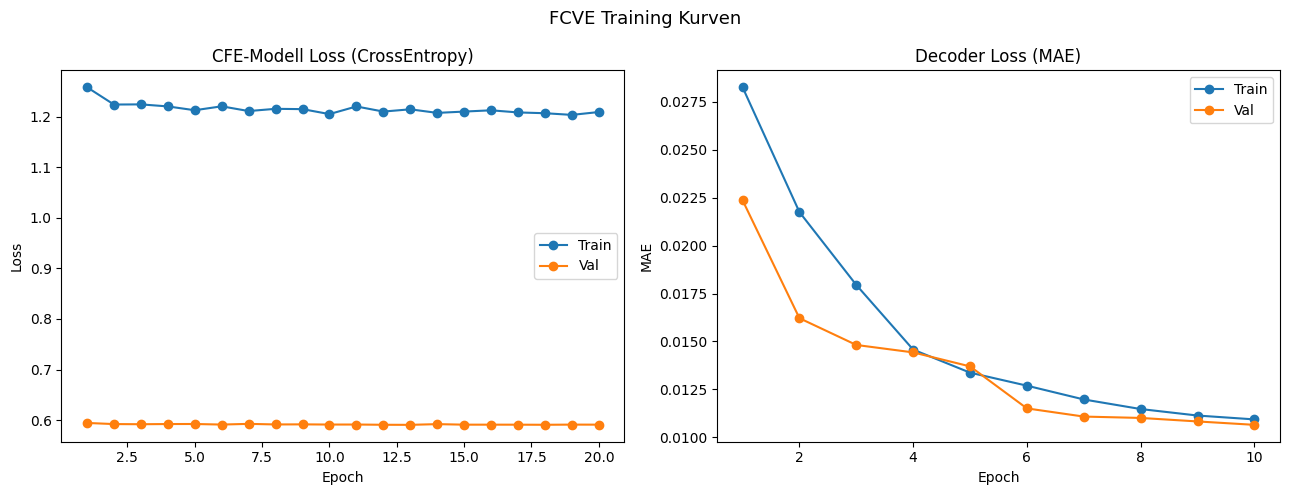

Trainingskurven gespeichert ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CFE-Modell
axes[0].plot(range(1, len(cfe_train_losses)+1), cfe_train_losses, 'o-', label='Train')
axes[0].plot(range(1, len(cfe_val_losses)+1),   cfe_val_losses,   'o-', label='Val')
axes[0].set_title('CFE-Modell Loss (CrossEntropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Decoder
axes[1].plot(range(1, len(dec_train_losses)+1), dec_train_losses, 'o-', label='Train')
axes[1].plot(range(1, len(dec_val_losses)+1),   dec_val_losses,   'o-', label='Val')
axes[1].set_title('Decoder Loss (MAE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('FCVE Training Kurven', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fcve_training_curves.png'), dpi=120)
plt.show()
print('Trainingskurven gespeichert ✓')

## 7. Decoder-Qualität prüfen (Rekonstruktion)

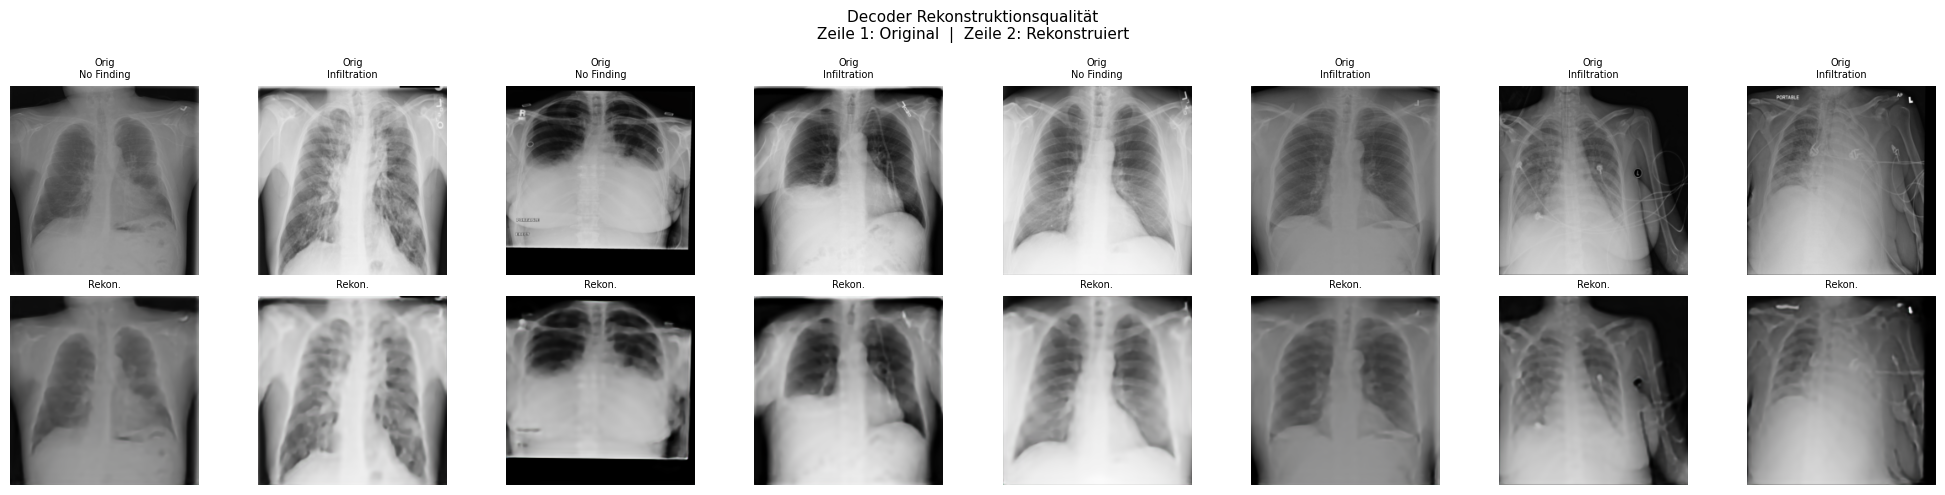

MAE auf Stichprobe: 0.0104  (niedriger = besser)

Alle Modelle gespeichert:
  /kaggle/working/fcve_cfe_model.pth
  /kaggle/working/fcve_decoder.pth
  /kaggle/working/fcve_training_curves.png
  /kaggle/working/fcve_reconstruction_check.png


In [10]:
def denormalise_cpu(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

# Stichprobe aus Val-Set
decoder.eval()
sample_imgs, sample_lbls = next(iter(val_loader))
sample_imgs = sample_imgs[:8].to(DEVICE)

with torch.no_grad():
    f1, f2, f3, f4, _ = extract_all_features(classifier, sample_imgs)
    recon = decoder(f4, f3, f2, f1)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    # Original
    orig_np = denormalise_cpu(sample_imgs[i].cpu()).permute(1,2,0).numpy()
    axes[0, i].imshow(orig_np, cmap='bone')
    axes[0, i].set_title(f'Orig\n{CLASS_NAMES[sample_lbls[i].item()]}', fontsize=7)
    axes[0, i].axis('off')

    # Rekonstruktion
    recon_np = tanh_to_img(recon[i].detach().cpu()).permute(1,2,0).numpy().clip(0,1)
    axes[1, i].imshow(recon_np, cmap='bone')
    axes[1, i].set_title('Rekon.', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Decoder Rekonstruktionsqualität\nZeile 1: Original  |  Zeile 2: Rekonstruiert', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fcve_reconstruction_check.png'), dpi=120)
plt.show()

mae_check = nn.L1Loss()(
    tanh_to_img(recon.detach().cpu()),
    denormalise_cpu(sample_imgs.cpu())
)
print(f'MAE auf Stichprobe: {mae_check.item():.4f}  (niedriger = besser)')
print('\nAlle Modelle gespeichert:')
print(f'  {OUT_DIR}/fcve_cfe_model.pth')
print(f'  {OUT_DIR}/fcve_decoder.pth')
print(f'  {OUT_DIR}/fcve_training_curves.png')
print(f'  {OUT_DIR}/fcve_reconstruction_check.png')